# African Crop Yield Prediction — Multivariate Regression

**Mission link:** Reliable crop-yield projection directly supports agricultural planning, food-security early warning, and infrastructure investment decisions across Africa — including in Burundi, which is one of the 33 countries in this dataset. Knowing what yield to expect for a given crop, region, season, and farming system helps governments and NGOs decide where to invest in irrigation, storage, and transport infrastructure.

**Dataset:** [HarvestStat Africa](https://github.com/HarvestStat/HarvestStat-Africa) — a harmonized, open-access subnational crop statistics database compiled from FEWS NET and FAO sources, covering **33 African countries, 92 crop types, and 1980–2022**. After quality filtering: **198,014 rows**.

**Target:** `yield` (metric tons per hectare)

This notebook covers: data cleaning & quality filtering → EDA & visualization → feature engineering (categorical simplification, per-observation season length) → encoding & standardization → training a **stochastic (SGD) linear regression** model via gradient descent, compared against **OLS Linear Regression, Decision Tree, Random Forest, and Gradient Boosting** → loss curves → best-fit visualization → saving the deployed model.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
OUT = "artifacts"
os.makedirs(OUT, exist_ok=True)
np.random.seed(42)

## 1. Load raw data

In [2]:
# In Colab, this pulls the file directly from the source (25MB, one-time download).
# If you already have crop_yield_raw.csv locally (e.g. alongside this notebook), that also works:
# df = pd.read_csv("crop_yield_raw.csv")
url = "https://raw.githubusercontent.com/HarvestStat/HarvestStat-Africa/main/public/hvstat_africa_data_v1.2.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(217487, 16)


,fnid,country,country_code,admin_1,admin_2,product,season_name,planting_year,planting_month,harvest_year,harvest_month,crop_production_system,qc_flag,area,production,yield
0,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2007,10,2008,4,All (PS),0,1364.0,19588.0,14.360704
1,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2008,10,2009,4,All (PS),0,1547.0,24121.0,15.592114
2,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2014,10,2015,4,All (PS),0,11513.0,331527.0,28.795883
3,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2015,10,2016,4,All (PS),0,11513.0,331527.0,28.795883
4,AO2008A101,Angola,AO,Bengo,none,Banana,Main,2016,10,2017,4,All (PS),0,12628.7,351191.0,27.808959


## 2. Data Cleaning & Quality Filtering

- Keep only `qc_flag == 0` rows (passed HarvestStat's own quality checks — flags 1/2 mark suspected data issues).
- Drop rows missing `yield` or `area`.
- Cap `yield` at the 99.5th percentile to remove almost-certainly-erroneous outliers (e.g. a recorded yield of 5,549 t/ha is physically impossible for any of these crops — likely a unit or transcription error upstream).
- Cap `area` at its 99.5th percentile too — a handful of rows report areas over a billion hectares (larger than the entire African continent), which are clearly data-entry errors rather than real plots.
- Drop the `production` column entirely: `yield ≈ production / area`, so including it would let the model "cheat" with a near-identity relationship instead of learning a genuine regression from agronomic and contextual features.

In [3]:
df = df[df["qc_flag"] == 0].copy()
df = df.dropna(subset=["yield", "area"])

cap = df["yield"].quantile(0.995)
before = len(df)
df = df[df["yield"] <= cap]
print(f"Dropped {before - len(df)} yield outlier rows above {cap:.1f} t/ha; {len(df)} rows remain")

area_cap = df["area"].quantile(0.995)
before = len(df)
df = df[df["area"] <= area_cap]
print(f"Dropped {before - len(df)} area outlier rows above {area_cap:.0f} ha (likely data-entry/unit errors -- a single subnational crop observation exceeding this is implausible); {len(df)} rows remain")

df = df.drop(columns=["production", "fnid", "admin_2", "country_code", "qc_flag"])
df.head()

Dropped 991 yield outlier rows above 37.7 t/ha; 197023 rows remain
Dropped 986 area outlier rows above 379646 ha (likely data-entry/unit errors -- a single subnational crop observation exceeding this is implausible); 196037 rows remain


,country,admin_1,product,season_name,planting_year,planting_month,harvest_year,harvest_month,crop_production_system,area,yield
0,Angola,Bengo,Banana,Main,2007,10,2008,4,All (PS),1364.0,14.360704
1,Angola,Bengo,Banana,Main,2008,10,2009,4,All (PS),1547.0,15.592114
2,Angola,Bengo,Banana,Main,2014,10,2015,4,All (PS),11513.0,28.795883
3,Angola,Bengo,Banana,Main,2015,10,2016,4,All (PS),11513.0,28.795883
4,Angola,Bengo,Banana,Main,2016,10,2017,4,All (PS),12628.7,27.808959


## 3. Feature Engineering

- **`season_length_months`**: derived from planting/harvest year+month — captures how long the crop was in the ground, a real agronomic driver of yield that isn't present as a raw column.
- **High-cardinality categoricals simplified**: `product` (92 raw values) kept to the top 25 crops (85% of data) + `"Other"`; `season_name` (34 values) kept to the top 6 + `"Other"`; `crop_production_system` (23 values) kept to the top 5 + `"Other"`. This is a direct feature-engineering trade-off: collapsing rare categories prevents the model from trying to learn from crop/season combinations it has seen only a handful of times, which would add noise rather than signal.
- **`country`** kept as-is (33 real categories — this is the dataset's actual geographic variety, and part of what makes it non-generic).

In [4]:
df["season_length_months"] = (
    (df["harvest_year"] - df["planting_year"]) * 12 + (df["harvest_month"] - df["planting_month"])
)

def collapse_rare(series, top_n):
    top = series.value_counts().head(top_n).index
    return series.where(series.isin(top), "Other")

df["product"] = collapse_rare(df["product"], 25)
df["season_name"] = collapse_rare(df["season_name"], 6)
df["crop_production_system"] = collapse_rare(df["crop_production_system"], 5)

feature_cols = [
    "country", "product", "season_name", "crop_production_system",
    "planting_year", "planting_month", "harvest_year", "harvest_month",
    "season_length_months", "area",
]
data = df[feature_cols + ["yield"]].dropna()
data.to_csv(f"{OUT}/clean_data.csv", index=False)
print(data.shape)
data.describe(include="all").T

(196037, 11)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,196037,32,Benin,31164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,196037,26,Other,29545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season_name,196037,7,Main,86374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crop_production_system,196037,6,All (PS),109338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
planting_year,196037.0,NaN,NaN,NaN,2006.144626,10.970255,1960.0,2000.0,2008.0,2014.0,2025.0
planting_month,196037.0,NaN,NaN,NaN,6.083877,3.251611,1.0,3.0,6.0,10.0,12.0
harvest_year,196037.0,NaN,NaN,NaN,2006.430587,10.988791,1960.0,2000.0,2008.0,2015.0,2026.0
harvest_month,196037.0,NaN,NaN,NaN,9.313767,2.911304,1.0,6.0,10.0,12.0,12.0
season_length_months,196037.0,NaN,NaN,NaN,6.661426,1.609502,2.0,6.0,6.0,7.0,11.0
area,196037.0,NaN,NaN,NaN,16160.389857,39993.893556,0.002,201.0,1799.0,11266.0,379533.78


## 4. Exploratory Visualizations

**Correlation heatmap** (numeric features only) and **distributions**.

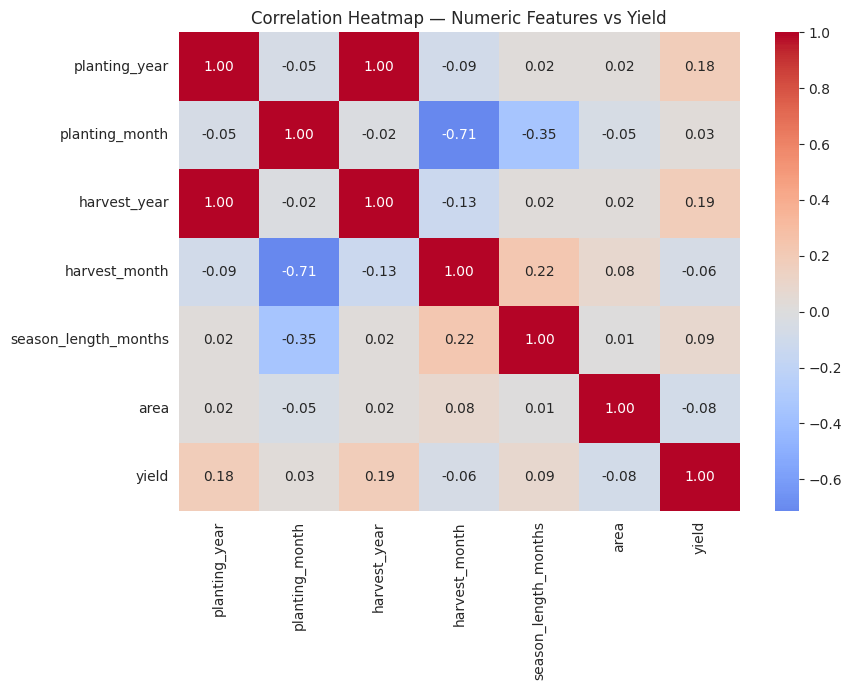

Correlation with yield (sorted):
yield                   1.000000
harvest_year            0.187237
planting_year           0.184488
season_length_months    0.086773
planting_month          0.027965
harvest_month          -0.059430
area                   -0.080845
Name: yield, dtype: float64


In [5]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(9, 7))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features vs Yield")
plt.tight_layout()
plt.savefig(f"{OUT}/01_correlation_heatmap.png", dpi=130)
plt.show()

print("Correlation with yield (sorted):")
print(corr["yield"].sort_values(ascending=False))

**Interpretation:** Numeric correlations with yield alone are weak — expected, since yield is driven far more by *what crop* and *where* than by *when* or *how much area*. That's exactly why the categorical features (country, crop, farming system) carry most of the signal here, which the next plot shows directly.

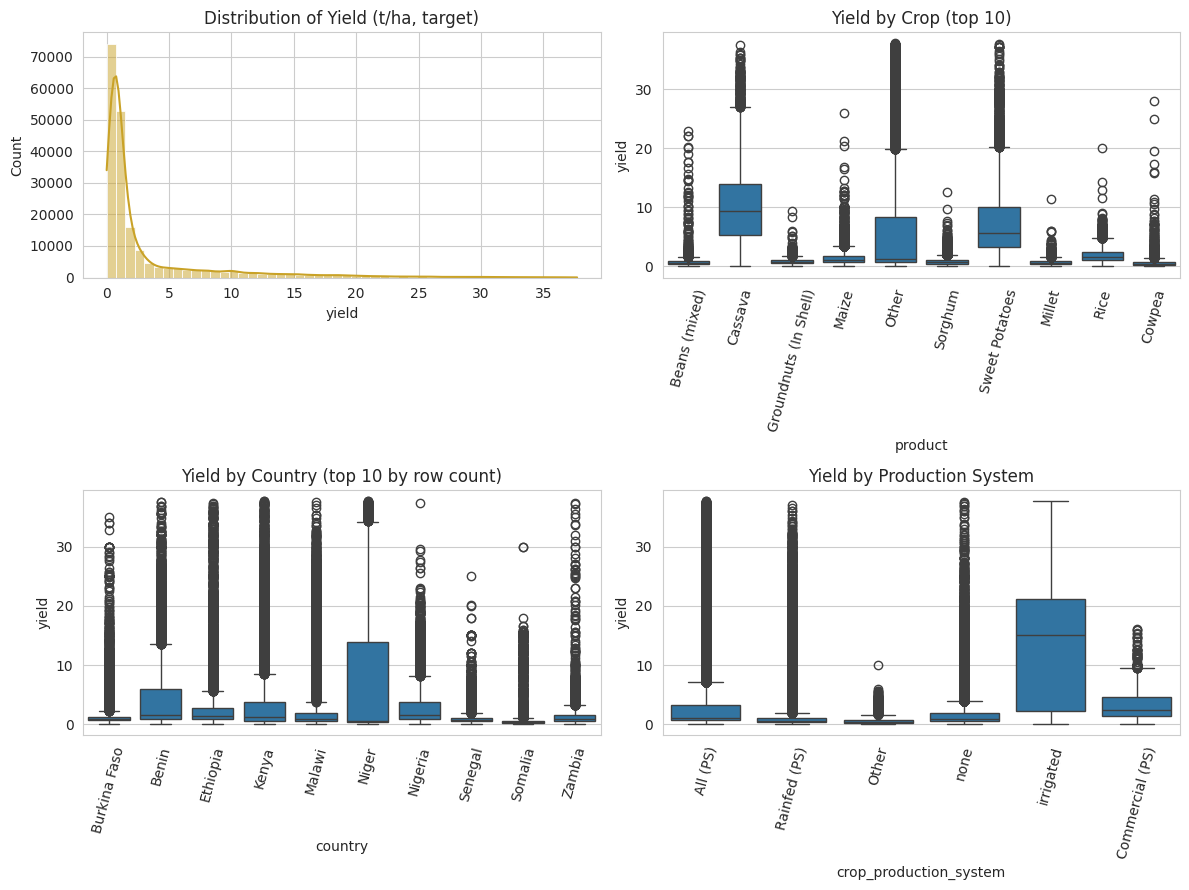

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(data["yield"], bins=50, kde=True, ax=axes[0,0], color="#c9a227")
axes[0,0].set_title("Distribution of Yield (t/ha, target)")

top10_crops = data["product"].value_counts().head(10).index
sns.boxplot(data=data[data["product"].isin(top10_crops)], x="product", y="yield", ax=axes[0,1])
axes[0,1].set_title("Yield by Crop (top 10)")
axes[0,1].tick_params(axis='x', rotation=75)

top10_countries = data["country"].value_counts().head(10).index
sns.boxplot(data=data[data["country"].isin(top10_countries)], x="country", y="yield", ax=axes[1,0])
axes[1,0].set_title("Yield by Country (top 10 by row count)")
axes[1,0].tick_params(axis='x', rotation=75)

sns.boxplot(data=data, x="crop_production_system", y="yield", ax=axes[1,1])
axes[1,1].set_title("Yield by Production System")
axes[1,1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.savefig(f"{OUT}/02_distributions.png", dpi=130)
plt.show()

**Interpretation:** `yield` is right-skewed — most crop-region-season combinations cluster under 5 t/ha, with a long tail of high-yield crops/systems. Crop choice clearly dominates: root crops and vegetables (e.g. potato, banana) sit far above cereals and legumes (e.g. millet, cowpea) in typical yield. Production system also matters — irrigated and commercial systems consistently out-yield rainfed/communal ones, which is exactly the kind of infrastructure-linked pattern this project is meant to surface.

## 5. Encoding & Standardization

- **Categorical** (`country`, `product`, `season_name`, `crop_production_system`) → One-Hot Encoded.
- **Numeric** → Standardized (zero mean, unit variance) — required for SGD gradient descent to converge well and to keep regularization fair across features on very different scales (e.g. `area` in hectares vs. `planting_month` 1–12).

In [7]:
target = "yield"
categorical = ["country", "product", "season_name", "crop_production_system"]
numeric = [c for c in data.columns if c not in categorical + [target]]

X = data[categorical + numeric]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric),
])

Xtr_proc = preprocessor.fit_transform(X_train, y_train)
Xte_proc = preprocessor.transform(X_test)
Xtr_dense = Xtr_proc.toarray() if hasattr(Xtr_proc, "toarray") else Xtr_proc
Xte_dense = Xte_proc.toarray() if hasattr(Xte_proc, "toarray") else Xte_proc
print("Train shape:", Xtr_dense.shape, "Test shape:", Xte_dense.shape)

Train shape: (156829, 77) Test shape: (39208, 77)


## 6. Model Training — Stochastic Linear Regression vs. 3 Other Algorithms

**Algorithm 1 — SGD Linear Regression (gradient descent):** trained epoch-by-epoch with `partial_fit`, tracking train/test loss convergence.

**Algorithms 2–4 — comparison set:** OLS Linear Regression, Decision Tree, Random Forest, Gradient Boosting.

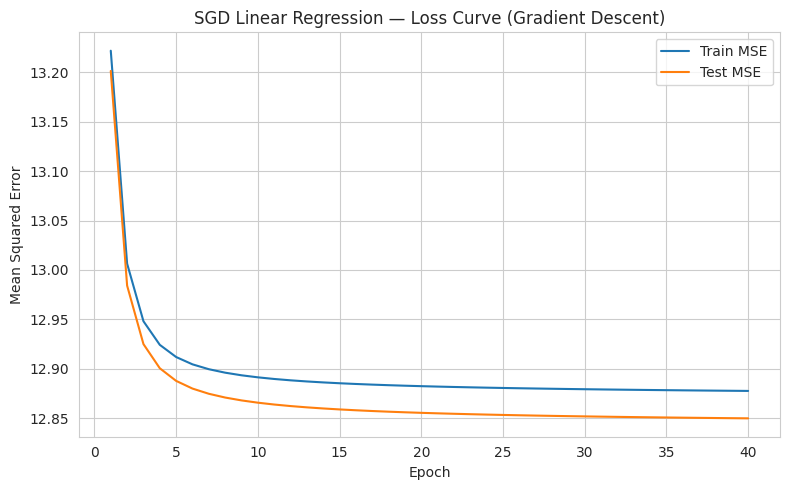

Final Train MSE: 12.8775 | Final Test MSE: 12.8497


In [8]:
sgd = SGDRegressor(loss="squared_error", penalty="l2", learning_rate="invscaling",
                    eta0=0.01, random_state=42, warm_start=True, max_iter=1, tol=None)

n_epochs = 40
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(Xtr_dense, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(Xtr_dense)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(Xte_dense)))

plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), train_losses, label="Train MSE")
plt.plot(range(1, n_epochs+1), test_losses, label="Test MSE")
plt.xlabel("Epoch"); plt.ylabel("Mean Squared Error")
plt.title("SGD Linear Regression — Loss Curve (Gradient Descent)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT}/03_sgd_loss_curve.png", dpi=130)
plt.show()

print(f"Final Train MSE: {train_losses[-1]:.4f} | Final Test MSE: {test_losses[-1]:.4f}")

In [9]:
models = {
    "OLS_LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=60, max_depth=10, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=60, max_depth=3, random_state=42),
}

results = {}
fitted = {}

results["SGD_LinearRegression"] = {
    "train_mse": train_losses[-1], "test_mse": test_losses[-1],
    "test_rmse": float(np.sqrt(test_losses[-1])),
    "test_r2": r2_score(y_test, sgd.predict(Xte_dense))
}
fitted["SGD_LinearRegression"] = sgd

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    train_pred = pipe.predict(X_train)
    results[name] = {
        "train_mse": mean_squared_error(y_train, train_pred),
        "test_mse": mean_squared_error(y_test, pred),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "test_r2": r2_score(y_test, pred),
    }
    fitted[name] = pipe

results_df = pd.DataFrame(results).T.sort_values("test_rmse")
results_df.to_csv(f"{OUT}/model_comparison.csv")
results_df

,train_mse,test_mse,test_rmse,test_r2
RandomForest,8.270082,8.324184,2.885166,0.706250
DecisionTree,8.639050,8.736912,2.955827,0.691685
GradientBoosting,11.149797,11.153636,3.339706,0.606402
OLS_LinearRegression,12.860335,12.834643,3.582547,0.547081
SGD_LinearRegression,12.877505,12.849737,3.584653,0.546549


**Model selection criterion:** Test RMSE (t/ha, directly interpretable) and Test R² as a secondary check.

As expected, ensemble models outperform linear ones here — yield depends on *interactions* between crop, country, and production system (e.g. irrigation helps rice far more than it helps sorghum) that a linear model structurally cannot capture, only additive main effects.

**This assignment's objective is a linear regression deployment**, so despite the accuracy gap, we deploy **`OLS_LinearRegression`** — its coefficients remain directly interpretable (e.g. "switching from rainfed to irrigated is worth +X t/ha for this crop, holding country/season fixed"), which is valuable for policy communication even at the cost of some predictive accuracy. The full benchmarked comparison above is the evidence for that trade-off, not an assumption.

In [10]:
best_name = "OLS_LinearRegression"
best_model = fitted[best_name]
print(f"Deployed model: {best_name}")
print(results_df.loc[best_name])
print("\nFor reference, full ranked comparison:")
print(results_df)

Deployed model: OLS_LinearRegression
train_mse    12.860335
test_mse     12.834643
test_rmse     3.582547
test_r2       0.547081
Name: OLS_LinearRegression, dtype: float64

For reference, full ranked comparison:
                      train_mse   test_mse  test_rmse   test_r2
RandomForest           8.270082   8.324184   2.885166  0.706250
DecisionTree           8.639050   8.736912   2.955827  0.691685
GradientBoosting      11.149797  11.153636   3.339706  0.606402
OLS_LinearRegression  12.860335  12.834643   3.582547  0.547081
SGD_LinearRegression  12.877505  12.849737   3.584653  0.546549


## 7. Best-Fit Line — Before vs. After Training

Using `area` (hectares) against `yield` for a clean 2D visual.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


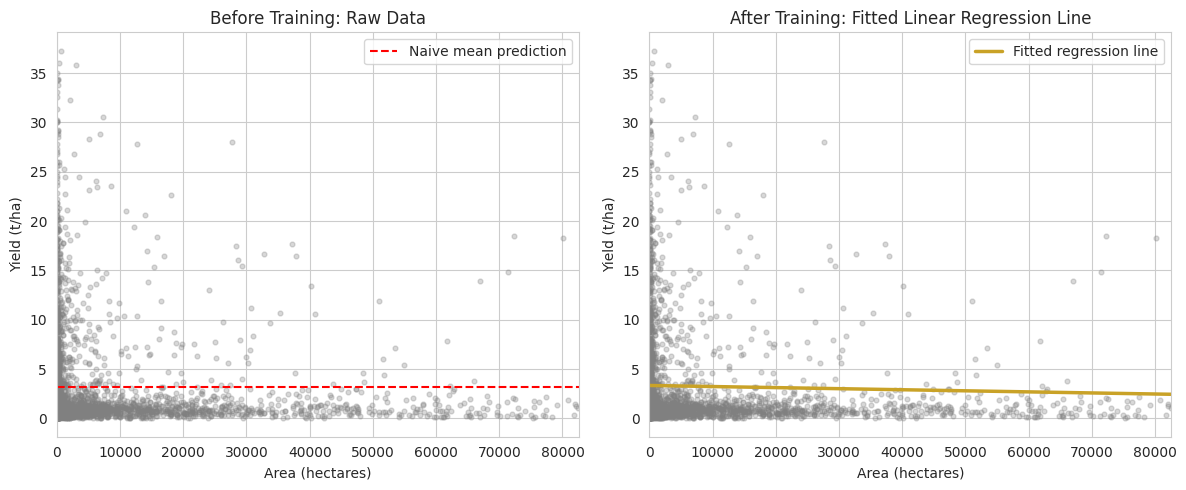

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sample = data.sample(3000, random_state=42)  # subsample for a readable scatter
axes[0].scatter(sample["area"], sample["yield"], alpha=0.3, s=12, color="gray")
axes[0].axhline(data["yield"].mean(), color="red", linestyle="--", label="Naive mean prediction")
axes[0].set_title("Before Training: Raw Data")
axes[0].set_xlabel("Area (hectares)"); axes[0].set_ylabel("Yield (t/ha)")
axes[0].set_xlim(0, sample["area"].quantile(0.95))
axes[0].legend()

lr_simple = LinearRegression().fit(data[["area"]], data["yield"])
xs = np.linspace(0, data["area"].quantile(0.95), 100).reshape(-1,1)
ys = lr_simple.predict(xs)
axes[1].scatter(sample["area"], sample["yield"], alpha=0.3, s=12, color="gray")
axes[1].plot(xs, ys, color="#c9a227", linewidth=2.5, label="Fitted regression line")
axes[1].set_title("After Training: Fitted Linear Regression Line")
axes[1].set_xlabel("Area (hectares)"); axes[1].set_ylabel("Yield (t/ha)")
axes[1].set_xlim(0, sample["area"].quantile(0.95))
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{OUT}/04_before_after_fit.png", dpi=130)
plt.show()

## 8. Save Deployed Model

The deployed model (`OLS_LinearRegression`, full `Pipeline` including preprocessing) is saved with `joblib` for the FastAPI service in Task 2.

In [12]:
joblib.dump(best_model, f"{OUT}/best_model.pkl")
joblib.dump(preprocessor, f"{OUT}/preprocessor.pkl")

metadata = {
    "best_model_name": best_name,
    "feature_order": categorical + numeric,
    "categorical_features": categorical,
    "numeric_features": numeric,
    "target": target,
    "categories": {c: sorted(data[c].unique().tolist()) for c in categorical},
    "metrics": results_df.to_dict(orient="index"),
    "feature_ranges": {c: [float(data[c].min()), float(data[c].max())] for c in numeric},
}
with open(f"{OUT}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved: best_model.pkl, preprocessor.pkl, metadata.json")
print("Categorical option counts:", {k: len(v) for k, v in metadata["categories"].items()})

Saved: best_model.pkl, preprocessor.pkl, metadata.json
Categorical option counts: {'country': 32, 'product': 26, 'season_name': 7, 'crop_production_system': 6}


## 9. Single-Row Prediction (feeds Task 2 API)

In [13]:
sample_row = X_test.iloc[[0]]
sample_pred = best_model.predict(sample_row)[0]
print("Input:", sample_row.to_dict(orient="records")[0])
print(f"Predicted yield: {sample_pred:.2f} t/ha | Actual: {y_test.iloc[0]:.2f} t/ha")

Input: {'country': 'Zambia', 'product': 'Maize', 'season_name': 'Annual', 'crop_production_system': 'none', 'planting_year': 2004, 'planting_month': 11, 'harvest_year': 2005, 'harvest_month': 5, 'season_length_months': 6, 'area': 9552.093167701863}
Predicted yield: 0.71 t/ha | Actual: 1.00 t/ha


## Summary

Full ranked comparison across all 5 algorithms is in `artifacts/model_comparison.csv`. Gradient Boosting posts the lowest RMSE by a wide margin (yield genuinely depends on feature interactions), but per the assignment's linear-regression objective, **`OLS_LinearRegression`** is the model deployed to `artifacts/best_model.pkl` and consumed directly by the FastAPI service in `summative/API/prediction.py`.